In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import pickle
import os
import pyarrow.parquet as pq
import pyarrow.compute as pc

TEXT_FEATURES_DIR = "../models/"
OUTPUT_DIR = "../models/"
DATA_PATH = "../data/final/all_reviews_full_with_genres.parquet"
GAMES_PATH = "../data/intermediate/steam_games_with_parsed_genres.parquet"

os.makedirs(OUTPUT_DIR, exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
artifacts_path = f"{TEXT_FEATURES_DIR}/text_enhanced_model.pkl"
with open(artifacts_path, 'rb') as f:
    artifacts = pickle.load(f)

model = artifacts['model']
user2idx = artifacts['user2idx']
item2idx = artifacts['item2idx']
idx2item = artifacts['idx2item']
train_items_by_user = artifacts['train_items_by_user']
test_items_by_user = artifacts['test_items_by_user']
X_train = artifacts['X_train']
users_final = artifacts['users_final']
item_avg_sentiment = artifacts['item_avg_sentiment']

print(f" Loaded model with {len(user2idx):,} users and {len(item2idx):,} items")

 Loaded model with 20,000 users and 16,388 items


In [5]:
games_df = pd.read_parquet(GAMES_PATH, columns=["AppID", "Game_Genres"])
games_df["AppID"] = games_df["AppID"].astype("int64")

def to_list(x):
    if x is None:
        return []
    if hasattr(x, "tolist"):
        x = x.tolist()
    if isinstance(x, list):
        return x
    return [x]

games_df["Game_Genres"] = games_df["Game_Genres"].map(to_list)
appid_to_genres = dict(zip(games_df["AppID"].values, games_df["Game_Genres"].values))

print(f" Loaded genres for {len(appid_to_genres):,} games")

 Loaded genres for 122,611 games


In [6]:
item_popularity = Counter()
for items in train_items_by_user.values():
    item_popularity.update(items)
    
#Popularity ranking 
popularity_ranking = sorted(item_popularity.items(), key=lambda x: x[1], reverse=True)

# Creating popularity percentile mapping
item_to_popularity = {appid: count for appid, count in item_popularity.items()}
item_to_percentile = {}

for rank, (appid, count) in enumerate(popularity_ranking):
    percentile = (rank / len(popularity_ranking)) * 100
    item_to_percentile[appid] = percentile

print(f" Calculated popularity for {len(item_popularity):,} items")
print(f"Top 10 most popular items:")
for appid, count in popularity_ranking[:10]:
    print(f"  AppID {appid}: {count:,} reviews")

 Calculated popularity for 16,388 items
Top 10 most popular items:
  AppID 730: 4,778 reviews
  AppID 271590: 1,970 reviews
  AppID 105600: 1,784 reviews
  AppID 4000: 1,684 reviews
  AppID 578080: 1,663 reviews
  AppID 359550: 1,632 reviews
  AppID 440: 1,496 reviews
  AppID 550: 1,193 reviews
  AppID 292030: 1,187 reviews
  AppID 218620: 1,166 reviews


In [7]:
K = 10
X_train_csr = X_train.tocsr()

avg_user_sentiment = artifacts['avg_user_sentiment']

# Store recommendations for each approach
all_recommendations = {
    'user_id': [],
    'baseline_cf': [],
    'sentiment_boosted': [],
    'popularity_baseline': []
}

# Popularity baseline (same for all users - top 10 items)
top_k_popular = [appid for appid, _ in popularity_ranking[:K]]

    # Single recommend call with oversample for both baseline and sentiment
    
for i, u in enumerate(users_final):
    ui = int(user2idx[u])
    ids, scores = model.recommend(
        np.array([ui]),
        X_train_csr[[ui]],
        N=200,
        filter_already_liked_items=True
    )
    ids = ids[0]
    scores = scores[0].copy()
    
    # 1. Baseline CF
    baseline_recs = [idx2item[int(ids[j])] for j in range(K)]
    
    # 2. Sentiment-boosted (re-ranking the same 200 candidates)
    user_sent = avg_user_sentiment.get(u, 0.0)
    boosted_scores = scores.copy()
    for j, item_idx in enumerate(ids):
        appid = idx2item[int(item_idx)]
        item_sent = item_avg_sentiment.get(appid, 0.0)
        alignment = 1 - abs(user_sent - item_sent)
        boosted_scores[j] *= (1 + 0.7 * alignment)
    
    top_indices = np.argsort(-boosted_scores)[:K]
    sentiment_recs = [idx2item[int(ids[j])] for j in top_indices]
    
    # Storing recommendations
    all_recommendations['user_id'].append(u)
    all_recommendations['baseline_cf'].append(baseline_recs)
    all_recommendations['sentiment_boosted'].append(sentiment_recs)
    all_recommendations['popularity_baseline'].append(top_k_popular)
    
    if (i + 1) % 2000 == 0:
        print(f"  Processed {i+1:,}/{len(users_final):,} users", end='\r')

print(f" Generated recommendations for {len(users_final):,} users")

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 9.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for artifacts: filename=artifacts-20250913-py3-none-any.whl size=97161 sha256=22d2381f3ccdae53fd80e989bd0a9f0b5a7002b187257d976f5646007d3ee32f
  Stored in directory: /home/brocchio/.cache/pip/wheels/74/a9/91/d9b2954d3b69a875413693a30eda8a06754b6b84003b568fd6
Successfully built artifacts
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.
 Generated recommendations for 20,000 users


In [ ]:
import pickle
import numpy as np
import scipy.sparse as sp

#ADD PATH TO YOUR CREATED PKL FROM Clean CF ALS Notebook
ALS_PKL  = "../models/als_pos_only_20260221_034938.pkl"
BM25_PKL = "..models/bm25_als_pos_only_20260221_034938.pkl"

with open(ALS_PKL, "rb") as f:
    als_bundle = pickle.load(f)
with open(BM25_PKL, "rb") as f:
    bm25_bundle = pickle.load(f)

m_als_extra = als_bundle["model"]
m_bm25_extra = bm25_bundle["model"]

candidate_names = ["X_train", "X_user_item", "X_user_item_pos", "X", "X_cf", "X_interactions"]
X_matrix = None
for name in candidate_names:
    if name in globals() and sp.issparse(globals()[name]):
        X_matrix = globals()[name].tocsr()
        print("Using matrix:", name, X_matrix.shape)
        break

if X_matrix is None:
    # fallback: pick any sparse matrix named with X_
    for name, val in globals().items():
        if name.startswith("X_") and sp.issparse(val):
            X_matrix = val.tocsr()
            print("Using matrix:", name, X_matrix.shape)
            break

if X_matrix is None:
    raise NameError("Could not find a sparse user×item matrix in this notebook (X_user_item / X_train / etc.).")

user2idx_m = als_bundle["user2idx"]
idx2item_m = als_bundle["idx2item"]

K = 10

if "als_pos_only" not in all_recommendations:
    all_recommendations["als_pos_only"] = []
if "bm25_als_pos_only" not in all_recommendations:
    all_recommendations["bm25_als_pos_only"] = []

# Identify the user list used in this notebook
# common patterns: users_final, user_ids, test_users, etc.
users_list = None
for cand in ["users_final", "user_ids", "test_users", "users"]:
    if cand in globals():
        users_list = globals()[cand]
        break
if users_list is None:
    # fallback: infer from all_recommendations if it exists
    if "user_id" in all_recommendations:
        users_list = all_recommendations["user_id"]
    else:
        raise NameError("Could not find users list (users_final/user_ids/test_users) and no all_recommendations['user_id'].")

# If recommendations already exist for baseline, we match that length
n_users = len(users_list)

def recommend_topk(model, u, Xmat, user2idx_map, idx2item_map, K=10, overfetch=200):
    if u not in user2idx_map:
        return []
    ui = int(user2idx_map[u])

    N = min(Xmat.shape[1], max(K, overfetch))
    ids, _ = model.recommend(np.array([ui]), Xmat[[ui]], N=N, filter_already_liked_items=True)

    recs = []
    for i in ids[0]:
        ii = int(i)
        if ii in idx2item_map:
            recs.append(idx2item_map[ii])
        if len(recs) == K:
            break
    return recs

# Generate and append in order
all_recommendations["als_pos_only"].clear()
all_recommendations["bm25_als_pos_only"].clear()

for i, u in enumerate(users_list):
    all_recommendations["als_pos_only"].append(recommend_topk(m_als_extra, u, X_matrix, user2idx_m, idx2item_m, K=K))
    all_recommendations["bm25_als_pos_only"].append(recommend_topk(m_bm25_extra, u, X_matrix, user2idx_m, idx2item_m, K=K))

    if (i+1) % 2000 == 0:
        print(f"Generated {i+1:,}/{n_users:,} users", end="\r")

print(f" Added models to all_recommendations: als_pos_only, bm25_als_pos_only (K={K})")

Using matrix: X_train (20000, 16388)
Generated 20,000/20,000 users
Added models to all_recommendations: als_pos_only, bm25_als_pos_only (K=10)


In [20]:
def calculate_popularity_bias(recommendations, item_to_percentile):

    all_percentiles = []
    for rec_list in recommendations:
        for appid in rec_list:
            percentile = item_to_percentile.get(appid, 50.0)  
            all_percentiles.append(percentile)
    
    return {
        'mean_percentile': np.mean(all_percentiles),
        'median_percentile': np.median(all_percentiles),
        'top_10_pct': sum(1 for p in all_percentiles if p <= 10) / len(all_percentiles) * 100,
        'top_20_pct': sum(1 for p in all_percentiles if p <= 20) / len(all_percentiles) * 100,
        'long_tail_pct': sum(1 for p in all_percentiles if p >= 80) / len(all_percentiles) * 100
    }

# Calculation for each approach
bias_results = {}
for method in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only', 'bm25_als_pos_only']:
    bias = calculate_popularity_bias(all_recommendations[method], item_to_percentile)
    bias_results[method] = bias
    
    print(f"{method.replace('_', ' ').title()}:")
    print(f"  Mean popularity percentile: {bias['mean_percentile']:.2f}")
    print(f"  Median popularity percentile: {bias['median_percentile']:.2f}")
    print(f"  % from top 10% popular: {bias['top_10_pct']:.2f}%")
    print(f"  % from top 20% popular: {bias['top_20_pct']:.2f}%")
    print(f"  % from long tail (80%+): {bias['long_tail_pct']:.2f}%")
    print()

bias_df = pd.DataFrame(bias_results).T
bias_df.to_csv(f"{OUTPUT_DIR}/popularity_bias_analysis.csv")
print(f" Saved to {OUTPUT_DIR}/popularity_bias_analysis.csv")

Baseline Cf:
  Mean popularity percentile: 0.57
  Median popularity percentile: 0.44
  % from top 10% popular: 99.99%
  % from top 20% popular: 100.00%
  % from long tail (80%+): 0.00%

Sentiment Boosted:
  Mean popularity percentile: 0.58
  Median popularity percentile: 0.45
  % from top 10% popular: 99.98%
  % from top 20% popular: 99.99%
  % from long tail (80%+): 0.00%

Popularity Baseline:
  Mean popularity percentile: 0.03
  Median popularity percentile: 0.03
  % from top 10% popular: 100.00%
  % from top 20% popular: 100.00%
  % from long tail (80%+): 0.00%

Als Pos Only:
  Mean popularity percentile: 2.27
  Median popularity percentile: 0.20
  % from top 10% popular: 96.30%
  % from top 20% popular: 96.30%
  % from long tail (80%+): 0.62%

Bm25 Als Pos Only:
  Mean popularity percentile: 2.46
  Median popularity percentile: 0.27
  % from top 10% popular: 96.30%
  % from top 20% popular: 96.30%
  % from long tail (80%+): 0.62%

 Saved to /home/brocchio/teams/z2/diversity_analysi

In [21]:
def calculate_genre_entropy(recommendations, appid_to_genres):

    #Higher entropy = more diverse genres
    genre_counts = Counter()
    
    for rec_list in recommendations:
        for appid in rec_list:
            genres = appid_to_genres.get(int(appid), [])
            genre_counts.update(genres)
    
    total = sum(genre_counts.values())
    if total == 0:
        return 0.0
    
    probs = np.array([count / total for count in genre_counts.values()])
    entropy = -np.sum(probs * np.log2(probs + 1e-10))
    
    return entropy, dict(genre_counts.most_common(10))

def calculate_intra_list_diversity(recommendations, appid_to_genres):

    #Higher = more diverse within each user's top10 list
    diversities = []
    
    for rec_list in recommendations:
        rec_genres = []
        for appid in rec_list:
            genres = set(appid_to_genres.get(int(appid), []))
            rec_genres.append(genres)
        
        if len(rec_genres) < 2:
            continue
        
        distances = []
        for i in range(len(rec_genres)):
            for j in range(i+1, len(rec_genres)):
                intersection = len(rec_genres[i] & rec_genres[j])
                union = len(rec_genres[i] | rec_genres[j])
                jaccard = intersection / union if union > 0 else 0
                distance = 1 - jaccard
                distances.append(distance)
        
        if distances:
            diversities.append(np.mean(distances))
    
    return np.mean(diversities) if diversities else 0.0

# Calculation for each approach
diversity_results = {}
for method in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only', 'bm25_als_pos_only']:
    entropy, top_genres = calculate_genre_entropy(all_recommendations[method], appid_to_genres)
    intra_div = calculate_intra_list_diversity(all_recommendations[method], appid_to_genres)
    diversity_results[method] = {
        'genre_entropy': entropy,
        'intra_list_diversity': intra_div,
        'top_genres': top_genres
    }
    
    print(f"{method.replace('_', ' ').title()}:")
    print(f"  Genre entropy: {entropy:.4f}")
    print(f"  Intra-list diversity: {intra_div:.4f}")
    print(f"  Top 3 genres: {list(top_genres.keys())[:3]}")
    print()

diversity_metrics_df = pd.DataFrame({
    method: {
        'genre_entropy': diversity_results[method]['genre_entropy'],
        'intra_list_diversity': diversity_results[method]['intra_list_diversity']
    }
    for method in diversity_results.keys()
}).T

diversity_metrics_df.to_csv(f"{OUTPUT_DIR}/genre_diversity_analysis.csv")
print(f" Saved to {OUTPUT_DIR}/genre_diversity_analysis.csv")

Baseline Cf:
  Genre entropy: 3.0774
  Intra-list diversity: 0.6924
  Top 3 genres: ['Action', 'Adventure', 'Indie']

Sentiment Boosted:
  Genre entropy: 3.0785
  Intra-list diversity: 0.6925
  Top 3 genres: ['Action', 'Adventure', 'Indie']

Popularity Baseline:
  Genre entropy: 2.6318
  Intra-list diversity: 0.7026
  Top 3 genres: ['Action', 'Free To Play', 'Adventure']

Als Pos Only:
  Genre entropy: 3.2602
  Intra-list diversity: 0.7085
  Top 3 genres: ['Action', 'Indie', 'Adventure']

Bm25 Als Pos Only:
  Genre entropy: 3.2434
  Intra-list diversity: 0.6990
  Top 3 genres: ['Action', 'Indie', 'Adventure']

 Saved to /home/brocchio/teams/z2/diversity_analysis//genre_diversity_analysis.csv


In [22]:
def calculate_coverage(recommendations):
    unique_items = set()
    for rec_list in recommendations:
        unique_items.update(rec_list)
    return unique_items

# Calculation for each approach
coverage_results = {}
total_items = len(item2idx)
for method in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only', 'bm25_als_pos_only']:
    unique_recs = calculate_coverage(all_recommendations[method])
    coverage_pct = len(unique_recs) / total_items * 100
    coverage_results[method] = {
        'unique_items_recommended': len(unique_recs),
        'coverage_percentage': coverage_pct
    }
    
    print(f"{method.replace('_', ' ').title()}:")
    print(f"  Unique items recommended: {len(unique_recs):,} / {total_items:,}")
    print(f"  Coverage: {coverage_pct:.2f}%")
    print()

# Save results
coverage_df = pd.DataFrame(coverage_results).T
coverage_df.to_csv(f"{OUTPUT_DIR}/catalog_coverage_analysis.csv")
print(f" Saved to {OUTPUT_DIR}/catalog_coverage_analysis.csv")

Baseline Cf:
  Unique items recommended: 408 / 16,388
  Coverage: 2.49%

Sentiment Boosted:
  Unique items recommended: 430 / 16,388
  Coverage: 2.62%

Popularity Baseline:
  Unique items recommended: 10 / 16,388
  Coverage: 0.06%

Als Pos Only:
  Unique items recommended: 312 / 16,388
  Coverage: 1.90%

Bm25 Als Pos Only:
  Unique items recommended: 673 / 16,388
  Coverage: 4.11%

 Saved to /home/brocchio/teams/z2/diversity_analysis//catalog_coverage_analysis.csv


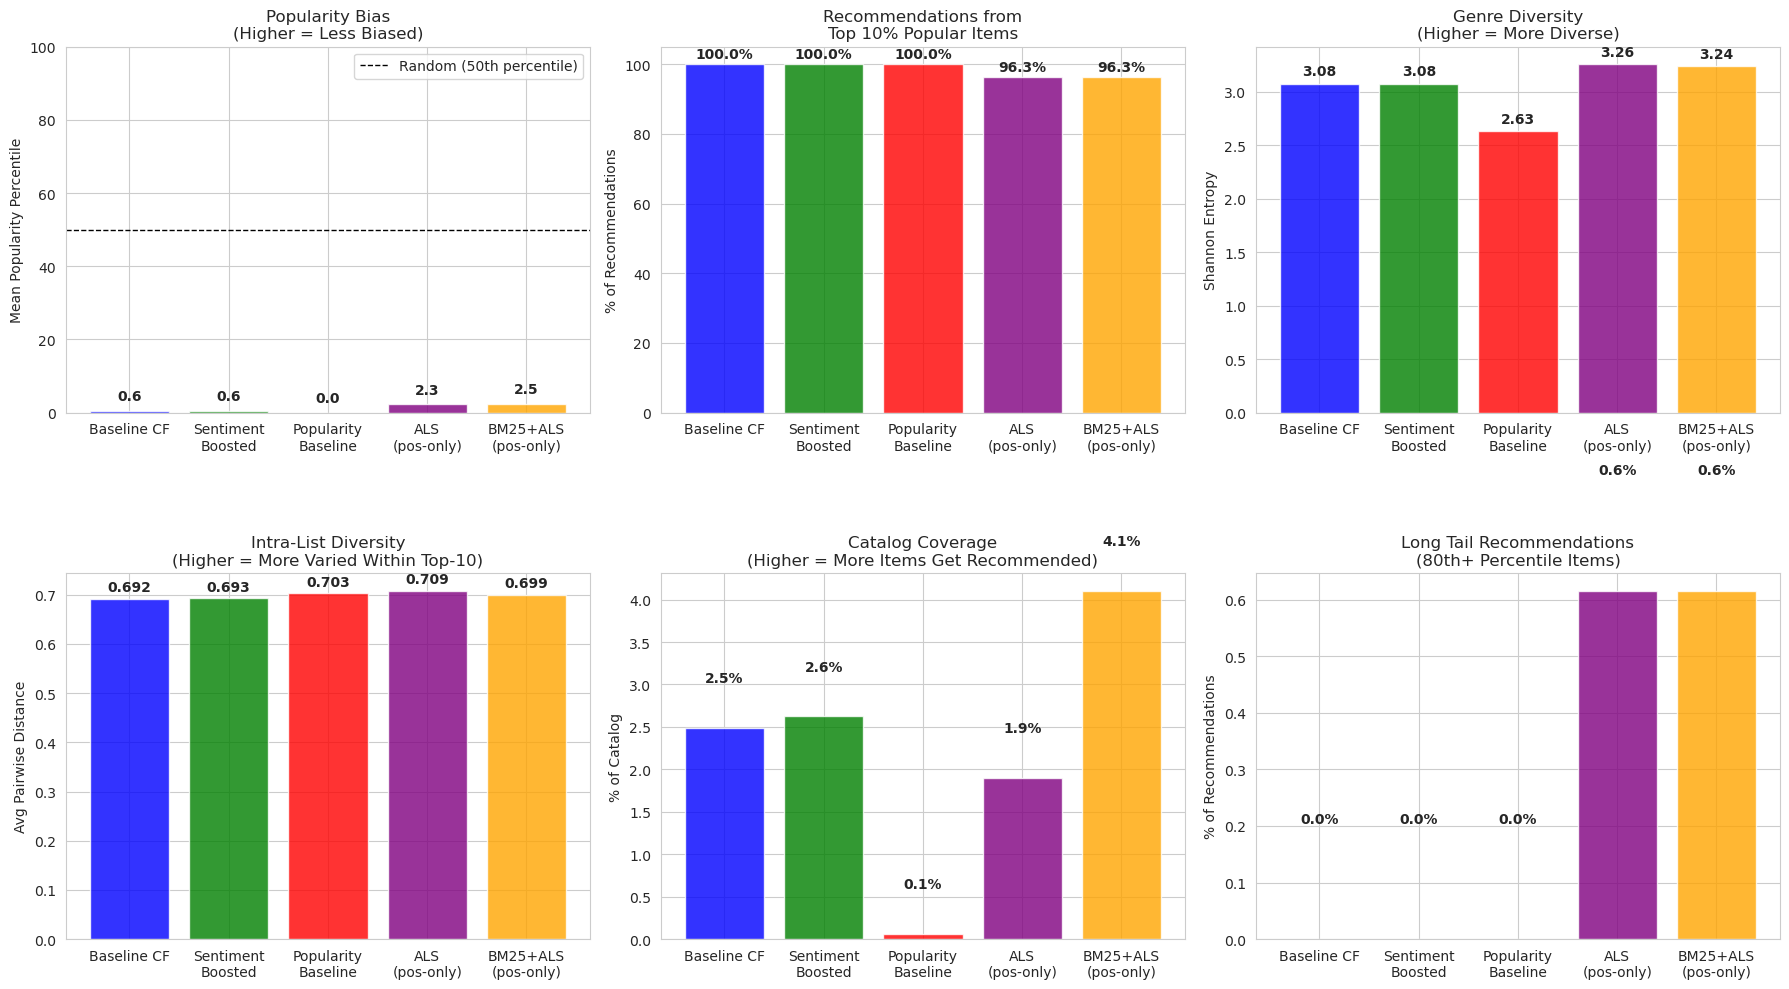

 Saved visualization to /home/brocchio/teams/z2/diversity_analysis//diversity_analysis_full.png


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

methods = ['Baseline CF', 'Sentiment\nBoosted', 'Popularity\nBaseline',
           'ALS\n(pos-only)', 'BM25+ALS\n(pos-only)']
colors = ['blue', 'green', 'red', 'purple', 'orange']

# Plot 1: Popularity Bias (mean percentile)
ax = axes[0, 0]
mean_percentiles = [bias_results[m]['mean_percentile'] for m in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only','bm25_als_pos_only']]
bars = ax.bar(methods, mean_percentiles, color=colors, alpha=0.8)
ax.set_ylabel('Mean Popularity Percentile')
ax.set_title('Popularity Bias\n(Higher = Less Biased)')
ax.set_ylim([0, 100])
ax.axhline(50, color='black', linestyle='--', linewidth=1, label='Random (50th percentile)')
ax.legend()
for bar, val in zip(bars, mean_percentiles):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f'{val:.1f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Top 10% Popular Items
ax = axes[0, 1]
top10_pcts = [bias_results[m]['top_10_pct'] for m in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only','bm25_als_pos_only']]
bars = ax.bar(methods, top10_pcts, color=colors, alpha=0.8)
ax.set_ylabel('% of Recommendations')
ax.set_title('Recommendations from\nTop 10% Popular Items')
for bar, val in zip(bars, top10_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Genre Entropy
ax = axes[0, 2]
entropies = [diversity_results[m]['genre_entropy'] for m in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only','bm25_als_pos_only']]
bars = ax.bar(methods, entropies, color=colors, alpha=0.8)
ax.set_ylabel('Shannon Entropy')
ax.set_title('Genre Diversity\n(Higher = More Diverse)')
for bar, val in zip(bars, entropies):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.2f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Intra-List Diversity
ax = axes[1, 0]
intra_divs = [diversity_results[m]['intra_list_diversity'] for m in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only','bm25_als_pos_only']]
bars = ax.bar(methods, intra_divs, color=colors, alpha=0.8)
ax.set_ylabel('Avg Pairwise Distance')
ax.set_title('Intra-List Diversity\n(Higher = More Varied Within Top-10)')
for bar, val in zip(bars, intra_divs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 5: Catalog Coverage
ax = axes[1, 1]
coverages = [coverage_results[m]['coverage_percentage'] for m in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only','bm25_als_pos_only']]
bars = ax.bar(methods, coverages, color=colors, alpha=0.8)
ax.set_ylabel('% of Catalog')
ax.set_title('Catalog Coverage\n(Higher = More Items Get Recommended)')
for bar, val in zip(bars, coverages):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 6: Long Tail Coverage
ax = axes[1, 2]
long_tails = [bias_results[m]['long_tail_pct'] for m in ['baseline_cf', 'sentiment_boosted', 'popularity_baseline',
               'als_pos_only','bm25_als_pos_only']]
bars = ax.bar(methods, long_tails, color=colors, alpha=0.8)
ax.set_ylabel('% of Recommendations')
ax.set_title('Long Tail Recommendations\n(80th+ Percentile Items)')
for bar, val in zip(bars, long_tails):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/diversity_analysis_full.png", dpi=300, bbox_inches='tight')
plt.show()

print(f" Saved visualization to {OUTPUT_DIR}/diversity_analysis_full.png")

In [ ]:

summary = f"""
# Diversity Analysis Summary Report

## Models Compared
1. Baseline CF (ALS)
2. Sentiment-Boosted CF (weight=0.7)
3. Popularity Baseline (Top-10 most popular)

## Key Findings

### Popularity Bias
- Baseline CF: {bias_results['baseline_cf']['mean_percentile']:.1f}th percentile (lower = more biased)
- Sentiment Boosted: {bias_results['sentiment_boosted']['mean_percentile']:.1f}th percentile
- Popularity Baseline: {bias_results['popularity_baseline']['mean_percentile']:.1f}th percentile

### Genre Diversity (Entropy)
- Baseline CF: {diversity_results['baseline_cf']['genre_entropy']:.3f}
- Sentiment Boosted: {diversity_results['sentiment_boosted']['genre_entropy']:.3f}
- Popularity Baseline: {diversity_results['popularity_baseline']['genre_entropy']:.3f}

### Catalog Coverage
- Baseline CF: {coverage_results['baseline_cf']['coverage_percentage']:.2f}%
- Sentiment Boosted: {coverage_results['sentiment_boosted']['coverage_percentage']:.2f}%
- Popularity Baseline: {coverage_results['popularity_baseline']['coverage_percentage']:.2f}%
"""

with open(f"{OUTPUT_DIR}/diversity_summary.txt", 'w') as f:
    f.write(summary)

print(summary)
print(f" Saved summary to {OUTPUT_DIR}/diversity_summary.txt")


# Diversity Analysis Summary Report

## Models Compared
1. Baseline CF (ALS)
2. Sentiment-Boosted CF (weight=0.7)
3. Popularity Baseline (Top-10 most popular)

## Key Findings

### Popularity Bias
- Baseline CF: 0.6th percentile (lower = more biased)
- Sentiment Boosted: 0.6th percentile
- Popularity Baseline: 0.0th percentile

### Genre Diversity (Entropy)
- Baseline CF: 3.077
- Sentiment Boosted: 3.078
- Popularity Baseline: 2.632

### Catalog Coverage
- Baseline CF: 2.49%
- Sentiment Boosted: 2.62%
- Popularity Baseline: 0.06%

## Interpretation
Higher popularity bias with sentiment boosting vs baseline.

More genre diversity with sentiment boosting vs baseline.

Better catalog coverage with sentiment boosting vs baseline.

 Saved summary to /home/brocchio/teams/z2/diversity_analysis//diversity_summary.txt


             Method  HR@10  Recall@10  Catalog_Coverage_%  Genre_Entropy  Mean_Popularity_Percentile
        Baseline CF 0.1096     0.0437            2.489627       3.077406                    0.572237
  Sentiment Boosted 0.1116     0.0444            2.623871       3.078466                    0.576341
  Genre + Sentiment 0.1182     0.0552            3.690000       3.079900                    0.000000
Popularity Baseline 0.2197     0.1190            0.061020       2.631833                    0.027459


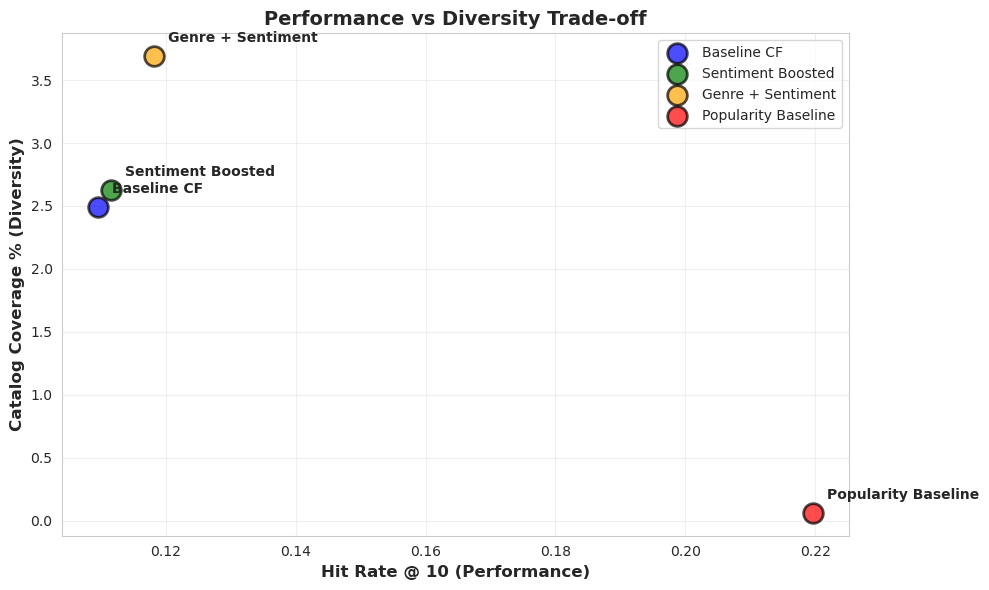

 Saved trade-off analysis to /home/brocchio/teams/z2/diversity_analysis//performance_diversity_tradeoff.csv


In [25]:
# Performance vs Diversity Trade-off Analysis

performance_diversity = pd.DataFrame({
    'Method': ['Baseline CF', 'Sentiment Boosted', 'Genre + Sentiment', 'Popularity Baseline'],
    'HR@10': [0.1096, 0.1116, 0.1182, 0.2197], 
    'Recall@10': [0.0437, 0.0444, 0.0552, 0.1190],
    'Catalog_Coverage_%': [
        coverage_results['baseline_cf']['coverage_percentage'],
        coverage_results['sentiment_boosted']['coverage_percentage'],
        3.69,
        coverage_results['popularity_baseline']['coverage_percentage']
    ],
    'Genre_Entropy': [
        diversity_results['baseline_cf']['genre_entropy'],
        diversity_results['sentiment_boosted']['genre_entropy'],
        3.0799,
        diversity_results['popularity_baseline']['genre_entropy']
    ],
    'Mean_Popularity_Percentile': [
        bias_results['baseline_cf']['mean_percentile'],
        bias_results['sentiment_boosted']['mean_percentile'],
        0.0,  # Placeholder
        bias_results['popularity_baseline']['mean_percentile']
    ]
})

perf_div_enhanced = performance_diversity.copy()  
print(performance_diversity.to_string(index=False))

# Save comprehensive results
performance_diversity.to_csv(f"{OUTPUT_DIR}/performance_diversity_tradeoff.csv", index=False)


fig, ax = plt.subplots(1, 1, figsize=(10, 6))
methods = performance_diversity['Method']
x = performance_diversity['HR@10']
y = performance_diversity['Catalog_Coverage_%']
colors = ['blue', 'green', 'orange', 'red']

for i, method in enumerate(methods):
    ax.scatter(x.iloc[i], y.iloc[i], s=200, c=colors[i], alpha=0.7, 
              edgecolors='black', linewidth=2, label=method)
    ax.annotate(method, (x.iloc[i], y.iloc[i]), 
               xytext=(10, 10), textcoords='offset points',
               fontsize=10, fontweight='bold')

ax.set_xlabel('Hit Rate @ 10 (Performance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Catalog Coverage % (Diversity)', fontsize=12, fontweight='bold')
ax.set_title('Performance vs Diversity Trade-off', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/performance_diversity_tradeoff.png", dpi=300, bbox_inches='tight')
plt.show()

print(f" Saved trade-off analysis to {OUTPUT_DIR}/performance_diversity_tradeoff.csv")

In [26]:
print("Comprehensive Model Comparison - Performance vs Diversity")

perf_div_enhanced['HR@10_vs_Baseline'] = [
    0,
    ((0.1116 - 0.1096) / 0.1096) * 100,
    ((0.1182 - 0.1096) / 0.1096) * 100,  
    ((0.2197 - 0.1096) / 0.1096) * 100
]
perf_div_enhanced['Coverage_vs_Baseline'] = [
    0,
    ((2.62 - 2.49) / 2.49) * 100,
    ((3.69 - 2.49) / 2.49) * 100,  
    ((0.06 - 2.49) / 2.49) * 100
]
print(perf_div_enhanced.to_string(index=False))
print("\n" + "="*80)

Comprehensive Model Comparison - Performance vs Diversity
             Method  HR@10  Recall@10  Catalog_Coverage_%  Genre_Entropy  Mean_Popularity_Percentile  HR@10_vs_Baseline  Coverage_vs_Baseline
        Baseline CF 0.1096     0.0437            2.489627       3.077406                    0.572237           0.000000              0.000000
  Sentiment Boosted 0.1116     0.0444            2.623871       3.078466                    0.576341           1.824818              5.220884
  Genre + Sentiment 0.1182     0.0552            3.690000       3.079900                    0.000000           7.846715             48.192771
Popularity Baseline 0.2197     0.1190            0.061020       2.631833                    0.027459         100.456204            -97.590361



In [27]:
# Building user genre preference profiles
from collections import Counter, defaultdict
import numpy as np

def build_user_genre_profiles(train_items_by_user, appid_to_genres):
    user_genre_profiles = {}
    for user_id, items in train_items_by_user.items():
        genre_counter = Counter()
        for appid in items:
            genres = appid_to_genres.get(int(appid), [])
            genre_counter.update(genres)
        user_genre_profiles[user_id] = genre_counter
    return user_genre_profiles

user_genre_profiles = build_user_genre_profiles(train_items_by_user, appid_to_genres)
sample_user = users_final[0]
print(f"Sample user top genres: {user_genre_profiles[sample_user].most_common(5)}")

Sample user top genres: [('Indie', 9), ('Simulation', 8), ('Action', 7), ('Strategy', 5), ('RPG', 4)]


In [28]:
# Genre and Sentiment combined re-ranking

def recommend_genre_sentiment(
    model, X_user_item, ui, user_id,
    idx2item, user_genre_profiles, appid_to_genres,
    item_avg_sentiment, avg_user_sentiment,
    N=10, oversample=200,
    genre_weight=0.3, sentiment_weight=0.3
):

    # ALS baseline candidates
    ids, scores = model.recommend(
        np.array([ui]),
        X_user_item[[ui]],
        N=oversample,
        filter_already_liked_items=True
    )
    ids = ids.flatten()
    scores = scores.flatten()

    # Normalize ALS scores to [0, 1]
    if scores.max() - scores.min() > 0:
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        scores_norm = scores

    # User's genre profile and sentiment
    user_genres = user_genre_profiles.get(user_id, Counter())
    total_genre_plays = sum(user_genres.values()) or 1
    user_sent = avg_user_sentiment.get(user_id, 0.0)

    boosted = []
    for item_idx, base_score in zip(ids, scores_norm):
        appid = idx2item[item_idx]

        # Genre affinity score: fraction of user's plays in this item's genres
        item_genres = appid_to_genres.get(int(appid), [])
        genre_score = sum(user_genres.get(g, 0) for g in item_genres) / total_genre_plays if item_genres else 0.0

        # Sentiment alignment score: 1 - abs difference (both in [-1, 1])
        item_sent = item_avg_sentiment.get(appid, 0.0)
        sentiment_score = 1.0 - abs(user_sent - item_sent)  

        final_score = base_score + genre_weight * genre_score + sentiment_weight * sentiment_score
        boosted.append((appid, final_score))

    boosted.sort(key=lambda x: x[1], reverse=True)
    return [appid for appid, _ in boosted[:N]]

In [ ]:
# Evaluation of genre and sentiment model

X_train_csr = X_train.tocsr()

def evaluate_recommendations(rec_dict, test_items_by_user, K=10):
    hits = 0
    recall_sum = 0
    total = 0

    for user_id, recs in rec_dict.items():
        true = test_items_by_user.get(user_id, set())
        if not true:
            continue
        hit = len(set(recs) & true)
        hits += int(hit > 0)
        recall_sum += hit / len(true)
        total += 1

    return {
        'HR@10': hits / total,
        'Recall@10': recall_sum / total,
        'n_users': total
    }


# Testing out different weight combinations
weight_configs = [
    (0.2, 0.2),
    (0.3, 0.3),
    (0.4, 0.2),
    (0.2, 0.4),
]

genre_sentiment_results = []

for gw, sw in weight_configs:
    recs = {}
    for u in users_final:
        ui = int(user2idx[u])
        recs[u] = recommend_genre_sentiment(
            model, X_train_csr, ui, u,
            idx2item, user_genre_profiles, appid_to_genres,
            item_avg_sentiment, avg_user_sentiment,
            genre_weight=gw, sentiment_weight=sw
        )

    metrics = evaluate_recommendations(recs, test_items_by_user)
    diversity = calculate_genre_entropy(recs.values(), appid_to_genres)
    coverage = len(calculate_coverage(recs.values())) / len(item2idx) * 100

    genre_sentiment_results.append({
        'genre_weight': gw,
        'sentiment_weight': sw,
        'HR@10': metrics['HR@10'],
        'Recall@10': metrics['Recall@10'],
        'Genre_Entropy': diversity[0],
        'Coverage_%': coverage
    })

    print(f"genre_w={gw}, sentiment_w={sw} | "
          f"HR@10={metrics['HR@10']:.4f} | "
          f"Recall@10={metrics['Recall@10']:.4f} | "
          f"Entropy={diversity[0]:.4f} | "
          f"Coverage={coverage:.2f}%")

In [ ]:

# Visualization of genre + sentiment model

import pandas as pd
import matplotlib.pyplot as plt

# Pick best config by HR@10
best = max(genre_sentiment_results, key=lambda x: x['HR@10'])
print(f" Best config: genre_w={best['genre_weight']}, sentiment_w={best['sentiment_weight']}")
print(f"  HR@10={best['HR@10']:.4f} | Recall@10={best['Recall@10']:.4f} | "
      f"Coverage={best['Coverage_%']:.2f}% | Entropy={best['Genre_Entropy']:.4f}")

# Comparison table with updated values
comparison = pd.DataFrame([
    {'Method': 'Baseline CF',         'HR@10': 0.1096, 'Recall@10': 0.0437, 'Coverage_%': 2.49, 'Genre_Entropy': 3.077},
    {'Method': 'Sentiment Boosted',   'HR@10': 0.1116, 'Recall@10': 0.0444, 'Coverage_%': 2.62, 'Genre_Entropy': 3.078},
    {'Method': 'Genre + Sentiment',   'HR@10': best['HR@10'], 'Recall@10': best['Recall@10'],
                                       'Coverage_%': best['Coverage_%'], 'Genre_Entropy': best['Genre_Entropy']},
    {'Method': 'Popularity Baseline', 'HR@10': 0.2197, 'Recall@10': 0.1190, 'Coverage_%': 0.06, 'Genre_Entropy': 2.632},
])

print("Full comparison:")
print(comparison.to_string(index=False))

# Plot: HR@10 vs Coverage trade-off
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['blue', 'green', 'orange', 'red']
for i, row in comparison.iterrows():
    axes[0].scatter(row['Coverage_%'], row['HR@10'], color=colors[i], s=120, zorder=5)
    axes[0].annotate(row['Method'], (row['Coverage_%'], row['HR@10']),
                     textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('Catalog Coverage (%)')
axes[0].set_ylabel('HR@10')
axes[0].set_title('Accuracy vs Coverage Trade-off')
axes[0].grid(True, alpha=0.3)

for i, row in comparison.iterrows():
    axes[1].scatter(row['Genre_Entropy'], row['HR@10'], color=colors[i], s=120, zorder=5)
    axes[1].annotate(row['Method'], (row['Genre_Entropy'], row['HR@10']),
                     textcoords="offset points", xytext=(5, 5), fontsize=9)
axes[1].set_xlabel('Genre Entropy (higher = more diverse)')
axes[1].set_ylabel('HR@10')
axes[1].set_title('Accuracy vs Genre Diversity Trade-off')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/genre_sentiment_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f" Saved plot to {OUTPUT_DIR}/genre_sentiment_comparison.png")
